# 🏠 Домашнее задание: Линейная регрессия

**Максимум: 10 баллов**

В этом задании вы будете работать с реальными данными о ценах на недвижимость в Бостоне (Boston Housing Dataset).

---

## Критерии оценивания

| Баллы | Критерий |
|-------|----------|
| **1** | Загрузка данных и первичный анализ (shape, info, describe) |
| **1** | Проверка на пропуски и выбросы |
| **1** | Правильное определение целевой переменной и обоснование выбора |
| **2** | Корректное разделение на X/y и train/test (с правильным использованием random_state) |
| **2** | Обучение модели и расчёт метрик (MAE, MSE, RMSE, R²) |
| **1** | Визуализация результатов (хотя бы один график) |
| **2** | Выводы: интерпретация метрик, анализ коэффициентов, предложения по улучшению |

**Итого: 10 баллов**

---

## Описание данных

Датасет содержит информацию о районах Бостона и ценах на жильё.

**Признаки:**
- `CRIM` — уровень преступности на душу населения
- `ZN` — доля жилой земли под участки более 25 000 кв.футов
- `INDUS` — доля нежилых коммерческих площадей
- `CHAS` — близость к реке Чарльз (1 = да, 0 = нет)
- `NOX` — концентрация оксидов азота
- `RM` — среднее количество комнат в доме
- `AGE` — доля домов, построенных до 1940 года
- `DIS` — расстояние до центров занятости Бостона
- `RAD` — индекс доступности к магистралям
- `TAX` — ставка налога на имущество
- `PTRATIO` — соотношение учеников к учителям
- `B` — показатель, связанный с долей афроамериканского населения
- `LSTAT` — процент населения с низким статусом
- `MEDV` — медианная стоимость домов (в $1000)

**Ваша задача:** определить целевую переменную, обучить модель линейной регрессии и проанализировать результаты.


---
## Задание 1. Загрузка и первичный анализ данных (1 балл)

Загрузите данные и проведите первичный анализ:
- Выведите размер датасета
- Посмотрите на типы данных
- Выведите описательную статистику


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/lyubovchubarova/MLHSELyceum2026/refs/heads/main/03_linreg/Boston.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.dtypes)
print("\nОписательная статистика:")
print(df.describe())

(506, 15)
Unnamed: 0      int64
crim          float64
zn            float64
indus         float64
chas            int64
nox           float64
rm            float64
age           float64
dis           float64
rad             int64
tax             int64
ptratio       float64
black         float64
lstat         float64
medv          float64
dtype: object

Описательная статистика:
       Unnamed: 0        crim          zn       indus        chas         nox  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean   253.500000    3.613524   11.363636   11.136779    0.069170    0.554695   
std    146.213884    8.601545   23.322453    6.860353    0.253994    0.115878   
min      1.000000    0.006320    0.000000    0.460000    0.000000    0.385000   
25%    127.250000    0.082045    0.000000    5.190000    0.000000    0.449000   
50%    253.500000    0.256510    0.000000    9.690000    0.000000    0.538000   
75%    379.750000    3.677083   12.500000   18.100000

---
## Задание 2. Проверка качества данных (1 балл)

- Проверьте наличие пропущенных значений
- Визуализируйте распределение признаков (гистограммы или boxplot)



crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


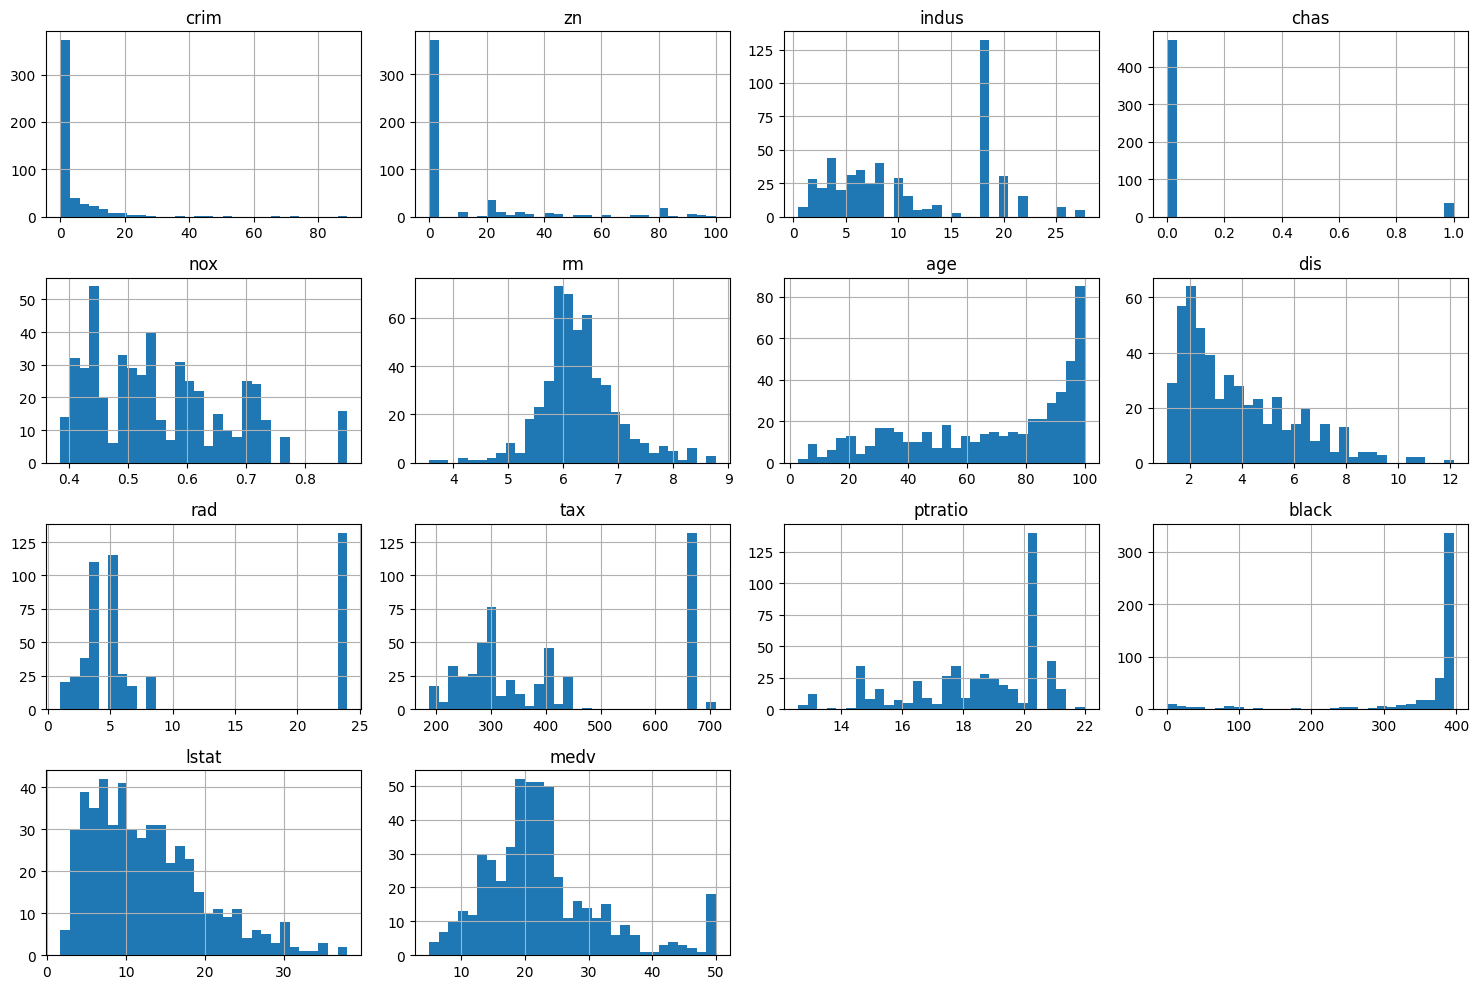

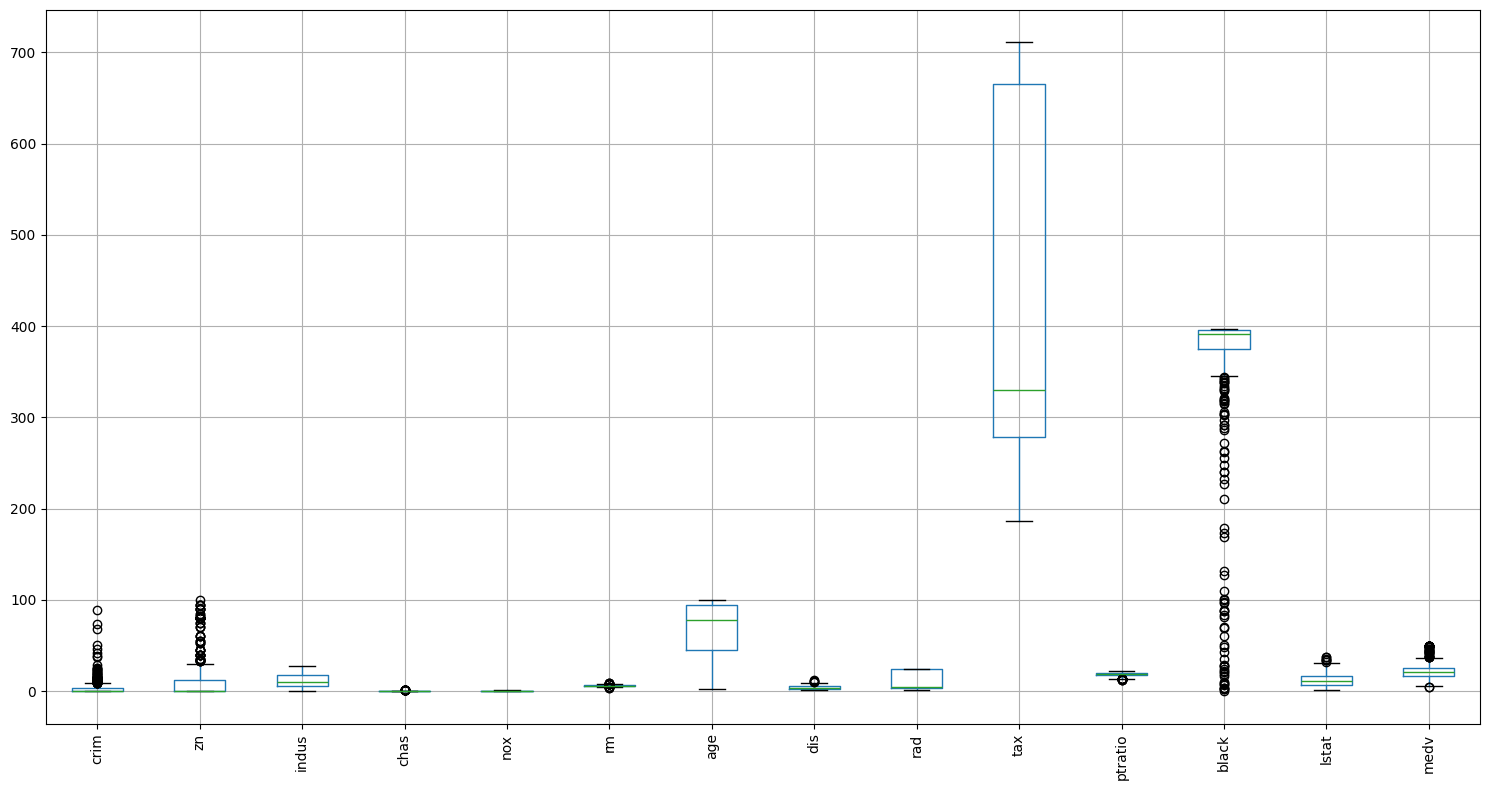

In [41]:
df = df.drop('Unnamed: 0', axis=1)
print(df.isnull().sum())

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
df.boxplot(rot=90)
plt.tight_layout()
plt.show()



Есть ли выбросы? Если да, как вы решите с ними поступить?



Выбросы есть, самые наглядные в: 
black

zn 

crim 

medv 

rm

Их можно логарифмировать 

In [42]:
df['crim'] = np.log1p(df['crim'])
df['zn'] = np.log1p(df['zn'])
df['black'] = np.log1p(df['black'])
df['medv'] = np.log1p(df['medv'])
df['rm'] = np.log1p(df['rm'])

---
## Задание 3. Определение целевой переменной (1 балл)

Изучите признаки датасета и определите:
- Какую переменную логичнее всего предсказывать?
- Почему вы выбрали именно её?




Целевая переменная: MEDV — медианная стоимость домов (в $1000)

Обоснование: Все остальные переменные, это признаки, которые влияют на стоимость домов 

---
## Задание 4. Подготовка данных (2 балла)

1. Разделите данные на признаки (X) и целевую переменную (y)
2. Разделите данные на train и test (80% / 20%)
3. Используйте `random_state=42` для воспроизводимости
4. Выведите размеры получившихся выборок

**Примечание:** Первый столбец датасета — это индекс, его нужно либо не загружать, либо удалить.


In [43]:

from sklearn.model_selection import train_test_split


X = df.drop('medv', axis=1)  # все признаки кроме цены
y = df['medv']  # цена дома


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)


print(f" X_train: {X_train.shape}")
print(f" X_test: {X_test.shape}")
print(f" y_train: {y_train.shape}")
print(f" y_test: {y_test.shape}")

 X_train: (404, 13)
 X_test: (102, 13)
 y_train: (404,)
 y_test: (102,)


---
## Задание 5. Обучение модели и метрики (2 балла)

1. Создайте и обучите модель `LinearRegression`
2. Сделайте предсказания на тестовой выборке
3. Посчитайте метрики:
   - MAE (Mean Absolute Error)
   - MSE (Mean Squared Error)
   - RMSE (Root Mean Squared Error)
   - R² (коэффициент детерминации)


In [44]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MAE: 0.13
MSE: 0.04
RMSE: 0.19
R²: 0.736


---
## Задание 6. Визуализация (1 балл)

Постройте хотя бы один из графиков:
- Scatter plot: предсказанные значения vs реальные (с диагональю y=x)
- Гистограмма ошибок (residuals)
- График коэффициентов модели


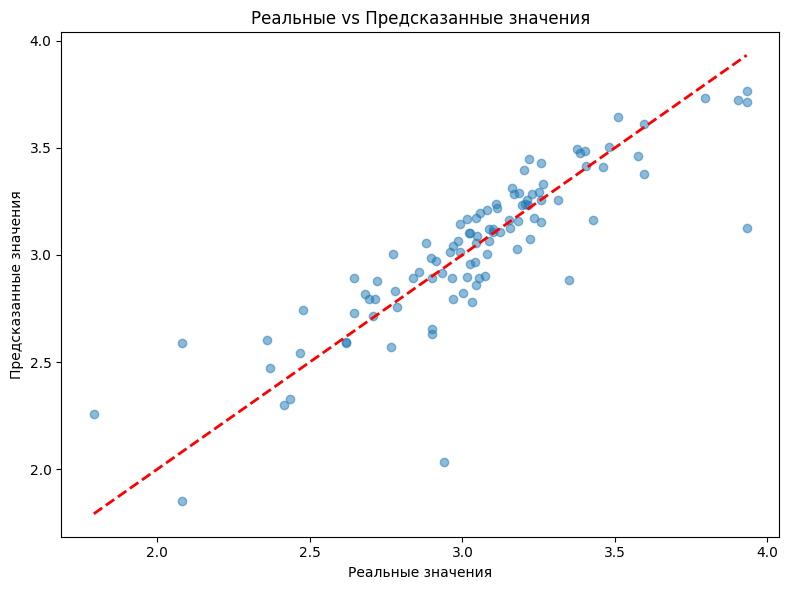

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Реальные vs Предсказанные значения')
plt.tight_layout()
plt.show()

---
## Задание 7. Анализ и выводы (2 балла)

Ответьте на следующие вопросы:

1. **Интерпретация метрик:**
   - Какой R² получился? Это хороший результат? (>0.7 — хорошо, >0.9 — отлично)
   - Что означает полученный MAE в контексте задачи?

2. **Анализ модели:**
   - Какие признаки больше всего влияют на цену дома? (посмотрите на коэффициенты модели)
   - Есть ли признаки с отрицательным влиянием? Логично ли это?

3. **Предложения по улучшению:**
   - Что можно сделать, чтобы улучшить качество модели?
   - Какие признаки можно было бы добавить/удалить/преобразовать?


**Ваши ответы:**

### 1. Интерпретация метрик

R² = 0.736 (хороший результат, потому что 73.6% вариаций модель объясняет)

MAE = 0.13  (означает, что в среднем модель ошибается на 0.13 тысячи долларов. Это очень хороший результат в контексте нашего задания) 

### 2. Анализ модели

Признаки с наибольшим положительным влиянием:
rm     0.692161
chas     0.098542
black     0.062949

Это логично, потому что: и в правду количество комнат всегда очень влияет. 

Признаки с наибольшим отрицательным влиянием:
nox    -0.572766
crim    -0.128765
 dis    -0.046341

Это логично, потому что: лодям важно своё здоровье, а на него напрямую влияет содержание оксидов азота. Уровень преступности всела важен, потому что это про безопасность. Ну и конечно же, люди хотят сократить дорогу до работы. 

### 3. Предложения по улучшению

- Попробовать другой тип регрессии

-  Удалить признаки, которые почти не влияют на цену, чтобы  модель стала проще  
git commit -m “


---
## Подсказка: как посмотреть коэффициенты

```python
# Коэффициенты модели
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)
```


In [47]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)



    feature  coefficient
5        rm     0.692161
4       nox    -0.572766
0      crim    -0.128765
3      chas     0.098542
11    black     0.062949
7       dis    -0.046341
10  ptratio    -0.039452
12    lstat    -0.027310
8       rad     0.016802
1        zn     0.006849
2     indus     0.002991
9       tax    -0.000445
6       age     0.000059
